In [2]:
import numpy as np
import random

### Creacion de entorno

In [3]:
dimension_tablero = (5,5)
pos_inicial = (0,0)
meta = (4,4)
obstaculos = [(1,1), (1,3), (2, 3), (3,0)]

### Acciones del pj

In [4]:
acciones= [(-1, 0), #arriba
           (1,0), #abajo
           (0, -1), #izquierda
           (0, 1) #derecha
           ]

In [5]:
estados_posibles = dimension_tablero[0] * dimension_tablero[1] # 5 * 5 = 25
num_acciones = len(acciones) # 4

In [6]:
Q = np.zeros((estados_posibles, num_acciones)) #Esto es un array rellenado con ceros y definimos la medida del mismo, esta es la que usa el algoritmo para hacer sus cálculos
print(Q)

[[0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]
 [0. 0. 0. 0.]]


## Encontrar a nuestro pj

In [7]:
def estado_a_indice(estado):
    return estado[0] * dimension_tablero[1] + estado[1]

In [8]:
ejemplo = estado_a_indice((1,0))
ejemplo

5

Esto lo que ha hecho ha sido encontrar en nuestro tablero original de 5x5 encontrar a nuestro personaje en base a la posicion del estado dado.<br>
Es como si jugasemos a los barquitos, tenemos la fila "`1`" que es la segunda y la columna "`0`" que es la primera:<br>
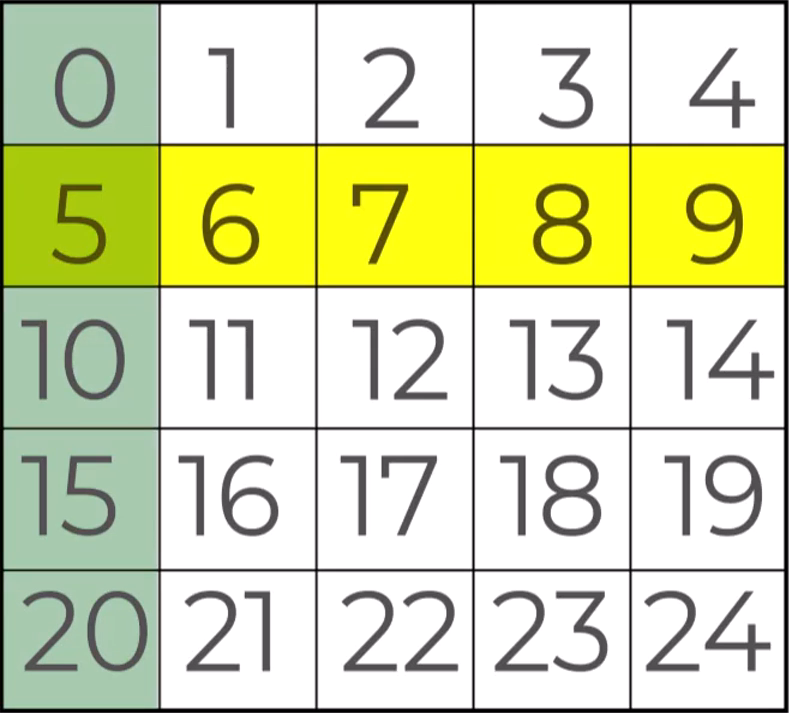 <br><br>
`alpha`: Tasa de aprendizaje, controla cuanto se actualiza q en la tasa de aprendizaje, un valor mas alto tiene aprendizaje mas rapido, pero puede ser menos estable<br>
`gamma`: Determinan la importancia de las decisiones que tome en el futuro, un valor cercano a uno hace que las recompensas futuras sean casi tan importantes que las inmediatas<br>
`epsilon`: Este valor es para que el agente no repita las mismas acciones, hace que tome una accion aleatoria en vez de la mejor accion conocida por Q. hace que explore en vez de explotar el conocimiento conocido<br>
`episodios`: es el total de veces que se va a repetir el entrenamiento<br>
_No son numeros definitivos, habrá que jugar con ellos para ver cual es la mejor combinación_

In [9]:
alpha = 0.1
gamma = 0.99
epsilon = 0.2
episodios = 100

In [10]:
def elegir_accion(estado):
    if random.uniform(0,1) < epsilon:
        return random.choice(range(num_acciones))
    else:
        return np.argmax(Q[estado_a_indice(estado)])

In [11]:
def aplicar_accion(estado, accion_idx):
    accion = acciones[accion_idx]
    nuevo_estado = tuple(np.add(estado, accion) % dimension_tablero)
    if nuevo_estado in obstaculos or nuevo_estado==estado:
        return estado, -100, False
    if nuevo_estado == meta:
        return nuevo_estado, 100, True
    return nuevo_estado, -1, False

In [12]:
for episodios in range(episodios):
    estado = pos_inicial
    terminado = False
    while not terminado:
        idx_estado = estado_a_indice(estado)
        accion_idx = int(elegir_accion(estado))
        nuevo_estado, recompensa, terminado = aplicar_accion(estado,accion_idx)
        idx_nuevo_estado = estado_a_indice(nuevo_estado)

        Q[idx_estado, accion_idx] = Q[idx_estado, accion_idx] + alpha * (recompensa + gamma * np.max(Q[idx_nuevo_estado]) - Q[idx_estado, accion_idx]) #esto es una formula

        estado = nuevo_estado

In [13]:
politica = np.zeros(dimension_tablero, dtype=int)
print(politica)

[[0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]
 [0 0 0 0 0]]


In [16]:
for i in range(dimension_tablero[0]):
    for j in range(dimension_tablero[1]):
        estado = (i,j)
        idx_estado = estado_a_indice(estado)
        mejor_accion = np.argmax(Q[idx_estado])
        politica[i,j] = mejor_accion

print("Politica aprendida: 0 arriba, 1 abajo, 2 izquierda, 3 derecha")
print(politica)

Politica aprendida: 0 arriba, 1 abajo, 2 izquierda, 3 derecha
[[2 2 3 3 0]
 [0 0 1 0 0]
 [1 2 0 0 0]
 [0 2 2 2 0]
 [2 2 3 2 0]]
100
